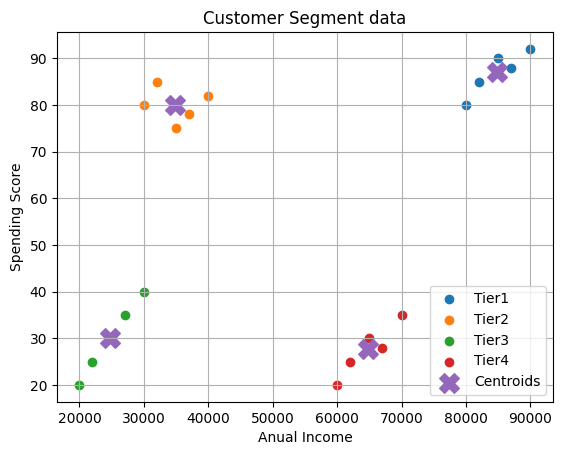

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create a dataframe
df = pd.read_csv("customer_segment.csv")

# select a specific columns
col = df[[' Annual_Income', ' Spending_Score']]

# create the standardised form of data
scaler = StandardScaler()
X_data = scaler.fit_transform(col)



# create a KMeans model
Kmean = KMeans(n_clusters=4, random_state=42, n_init= 20)
y_Kmean = Kmean.fit_predict(X_data)

df["Cluster"] = y_Kmean

# plot the original data for differetiate
orginal_X_data = scaler.inverse_transform(X_data)
Centroid = scaler.inverse_transform(Kmean.cluster_centers_)

# ploting Data
plt.scatter(orginal_X_data[y_Kmean == 0, 0], orginal_X_data[y_Kmean == 0, 1], label='Tier1')
plt.scatter(orginal_X_data[y_Kmean == 3, 0], orginal_X_data[y_Kmean == 3, 1], label='Tier2')
plt.scatter(orginal_X_data[y_Kmean == 2, 0], orginal_X_data[y_Kmean == 2, 1], label='Tier3')
plt.scatter(orginal_X_data[y_Kmean == 1, 0], orginal_X_data[y_Kmean == 1, 1], label='Tier4')

# Create centroid

plt.scatter(Centroid[:, 0],
            Centroid[:, 1],
            s=200, marker='X' ,label='Centroids')
plt.title("Customer Segment data")
plt.xlabel("Anual Income")
plt.ylabel("Spending Score")
plt.grid(True)
plt.legend()
plt.show()




In [14]:
df.max()

CustomerID            20
 Annual_Income     90000
 Spending_Score       92
Cluster                3
dtype: int64

Text(0, 0.5, 'WCSS')

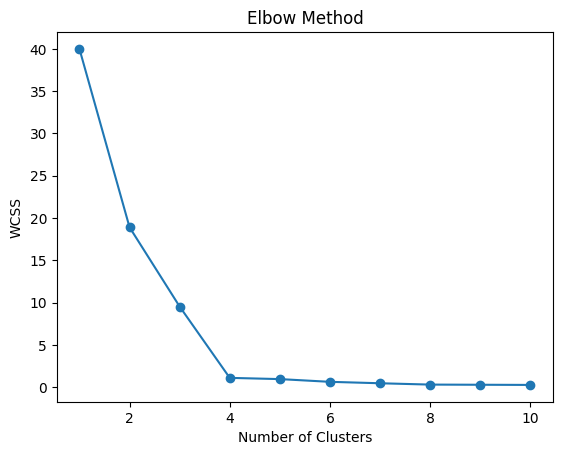

In [15]:
# import modules
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# read the csv file
df = pd.read_csv("customer_segment.csv")

# filter the data we want
col = df[[' Annual_Income', ' Spending_Score']]

# scale the data
scaler = StandardScaler()
X_data = scaler.fit_transform(col)

# Elbow Method
wcs = []
for i in range(1,11):
    Kmean = KMeans(n_clusters=i, random_state=42)
    Kmean.fit(X_data)
    wcs.append(Kmean.inertia_)
# Plot the data 
plt.plot(range(1, 11), wcs, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
